# Chesapeake Bay Nutrient Loads — Quick Look Demo

A first-look exploration of the [`OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads`](https://huggingface.co/datasets/BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads) dataset: load, inspect, and visualize 14,200 monthly nutrient observations from 121 USGS gauges across the Chesapeake watershed (2014–2021).

## What You'll Learn

- How to pull the dataset directly from Hugging Face with `datasets.load_dataset`
- The schema and value ranges for nitrogen, phosphorus, and sediment loads
- The spatial layout of monitoring stations across sub-basins
- How monthly nutrient loads vary at a representative station

## Why

For Civil & Environmental Engineering practitioners new to this dataset, a 5-minute orientation to the schema, geography, and signal strength is the fastest path to deciding whether the data fits a research or planning question.

## Requirements

- Python 3.11
- `pandas`, `matplotlib`, `datasets`, `numpy` (see `requirements.txt`)
- ~1 minute runtime on a laptop, no GPU required

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight' 

## 1. Load the dataset

Pull straight from the Hugging Face Hub. First call downloads (~few MB); later calls hit the local cache.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Frank\.cache\huggingface\hub\datasets--BAIGroup--OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14166 [00:00<?, ? examples/s]

Rows: 14,166
Columns: 19


,STAID,Year,Month,sediment_load,tn_load,tp_load,sediment_load_class,tn_load_class,tp_load_class,sediment_load_flow_norm,tn_load_flow_norm,tp_load_flow_norm,station_name,latitude,longitude,huc,state_code,subbasin,task_id
0,01486000,2014,1,668.0,88.1,4.06,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
1,01486000,2014,2,1360.0,117.0,6.52,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
2,01486000,2014,3,1780.0,109.0,7.15,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
3,01486000,2014,4,876.0,62.9,4.15,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6
4,01486000,2014,5,1980.0,64.3,6.43,0.0,0,0.0,True,True,True,"MANOKIN BRANCH NEAR PRINCESS ANNE, MD",38.213889,-75.671389,2080110,24,patuxent_choptank,ac29abf9-3e8e-5e98-b071-c49e36c94fc6


## 2. Schema and ranges

Every record is one (station × year × month) observation. Three load metrics — total nitrogen (`tn_load`), total phosphorus (`tp_load`), and `sediment_load` — each with a corresponding quantile-bin class label (`*_class`, integer 0–3) and a flow-normalization flag.

In [3]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "non_null": df.notna().sum(),
})
schema

,dtype,n_unique,non_null
STAID,object,121,14166
Year,int64,10,14166
Month,int64,12,14166
sediment_load,float64,3525,12654
tn_load,float64,3242,14166
tp_load,float64,3296,12762
sediment_load_class,float64,4,12654
tn_load_class,int64,4,14166
tp_load_class,float64,4,12762
sediment_load_flow_norm,object,1,12654


In [4]:
df[['tn_load', 'tp_load', 'sediment_load']].describe()

,tn_load,tp_load,sediment_load
count,14166.000000,12762.000000,1.265400e+04
mean,16524.180061,1383.642457,1.221760e+06
std,54731.150465,3849.979555,3.662162e+06
min,6.330000,0.384000,1.920000e+02
25%,497.250000,45.325000,2.142500e+04
50%,2010.000000,148.000000,9.455000e+04
75%,7020.000000,597.750000,3.800000e+05
max,650000.000000,41000.000000,4.040000e+07


## 3. Where are the stations?

121 USGS gauges spread across the Chesapeake watershed, grouped by sub-basin category.

Unique stations: 121
Sub-basins (4): ['james', 'patuxent_choptank', 'potomac', 'susquehanna']


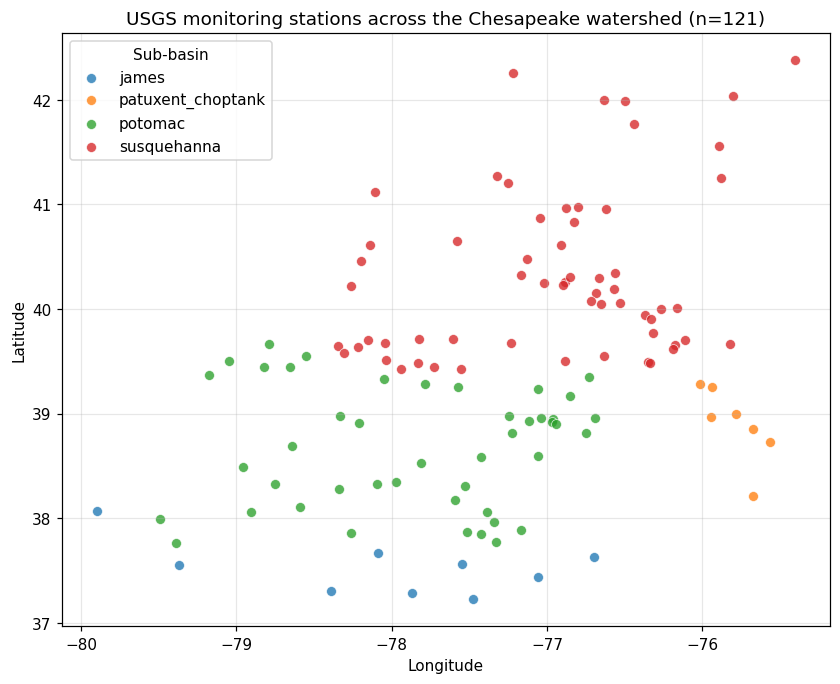

In [5]:
stations = (
    df[['STAID', 'station_name', 'latitude', 'longitude', 'subbasin']]
    .drop_duplicates(subset='STAID')
    .reset_index(drop=True)
)
print(f"Unique stations: {len(stations)}")
print(f"Sub-basins ({stations['subbasin'].nunique()}): {sorted(stations['subbasin'].unique().tolist())}")

fig, ax = plt.subplots(figsize=(9, 7))
for sb in sorted(stations['subbasin'].unique()):
    s = stations[stations['subbasin'] == sb]
    ax.scatter(s['longitude'], s['latitude'], label=sb, s=42, alpha=0.78,
               edgecolor='white', linewidth=0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"USGS monitoring stations across the Chesapeake watershed (n={len(stations)})")
ax.legend(title="Sub-basin", loc='best')
ax.grid(alpha=0.3)
plt.show()

## 4. Time series for a representative station

Pick the station with the most monthly observations and plot its three load series over time. A log scale is used since loads vary across several orders of magnitude.

Most-observed station: 01491000 — CHOPTANK RIVER NEAR GREENSBORO, MD


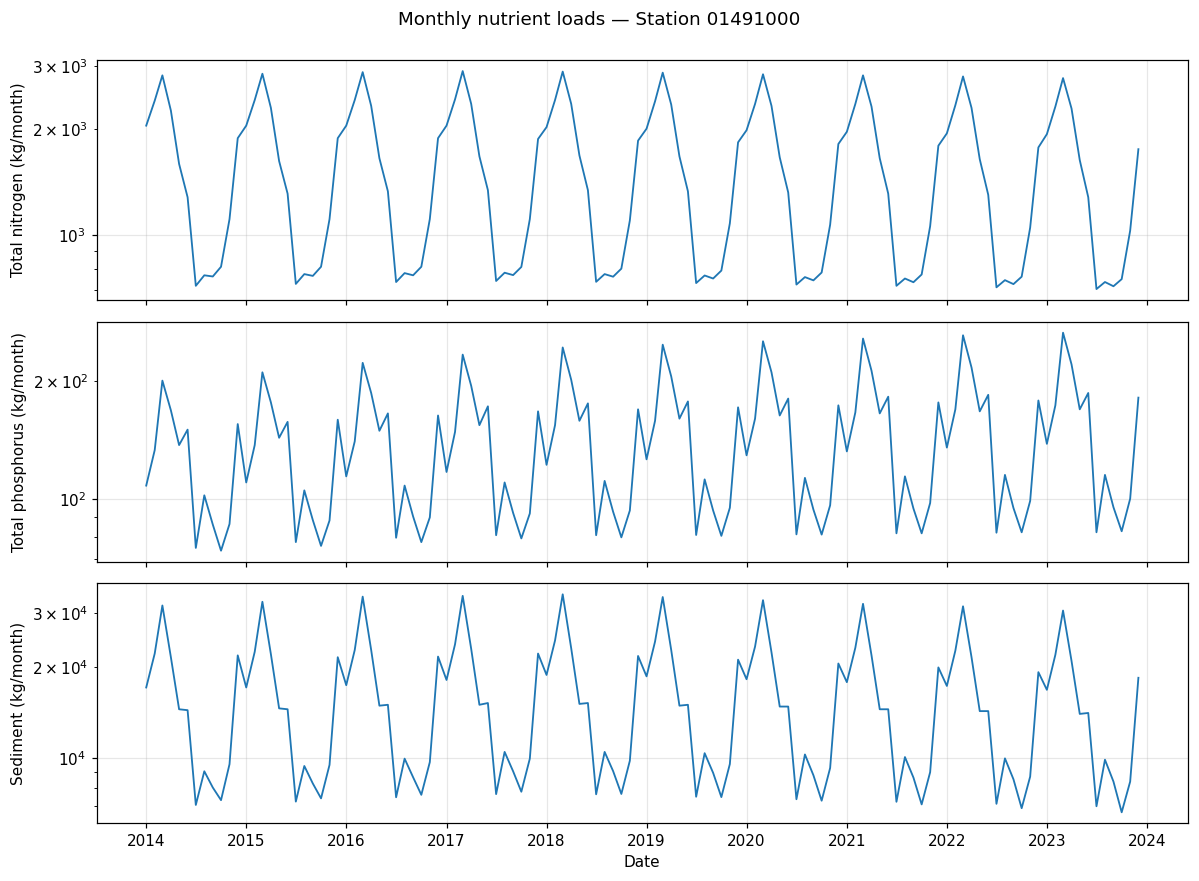

In [6]:
top_station = df['STAID'].value_counts().index[0]
top_name = df.loc[df['STAID'] == top_station, 'station_name'].iloc[0]
print(f"Most-observed station: {top_station} — {top_name}")

s = df[df['STAID'] == top_station].copy()
s['date'] = pd.to_datetime({'year': s['Year'], 'month': s['Month'], 'day': 1})
s = s.sort_values('date')

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
metrics = [('tn_load', 'Total nitrogen (kg/month)'),
           ('tp_load', 'Total phosphorus (kg/month)'),
           ('sediment_load', 'Sediment (kg/month)')]
for ax, (col, label) in zip(axes, metrics):
    ax.plot(s['date'], s[col], lw=1.2)
    ax.set_ylabel(label)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Date")
fig.suptitle(f"Monthly nutrient loads — Station {top_station}", y=0.995)
plt.tight_layout()
plt.show()

## 5. Quantile-bin class distribution

Each load metric carries a 0–3 class label assigned by quantile bin (low / mid-low / mid-high / high). Distributions are roughly balanced by construction.

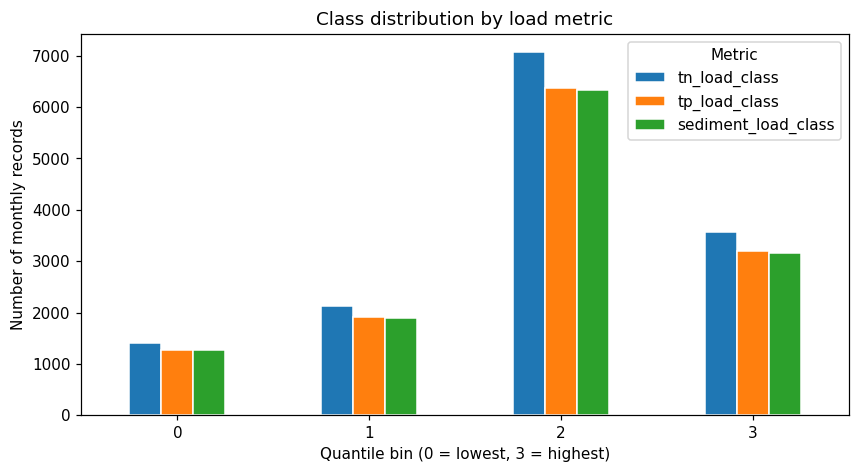

,tn_load_class,tp_load_class,sediment_load_class
0,1409,1277,1267
1,2118,1914,1897
2,7070,6380,6330
3,3569,3191,3160


In [7]:
class_cols = ['tn_load_class', 'tp_load_class', 'sediment_load_class']
class_counts = pd.DataFrame({col: df[col].value_counts().sort_index() for col in class_cols})

ax = class_counts.plot(kind='bar', figsize=(9, 4.5), edgecolor='white')
ax.set_xlabel("Quantile bin (0 = lowest, 3 = highest)")
ax.set_ylabel("Number of monthly records")
ax.set_title("Class distribution by load metric")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.show()
class_counts

## What's Next

- **`02_data_prep_reproduce.ipynb`** — rebuild the dataset end-to-end from raw USGS NWIS pulls.
- **`03_tutorial_embeddings_rf.ipynb`** — predict load classes from OlmoEarth embeddings using a Random Forest.
- **`04_analysis_results.ipynb`** — cross-station results and key findings.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*